# Imports & setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import os

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
confusion_matrix, classification_report, roc_auc_score, roc_curve)

In [10]:
# File
df = pd.read_csv(r"C:\Users\rrama_t5uaug6\Downloads\archive (8)\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
# Basic navigation and understanding
print("Dataset Shape:", df.shape)
print("\nColumns:")
print
(df.columns)
print
("\nDataset Info:")
df.info()
print
("\nSummary Statistics:")
df.describe()

Dataset Shape: (7043, 21)

Columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperl

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Clean and preprocessing

In [14]:
# Missing Values Check
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [15]:
# Clean TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges before fix:", df["TotalCharges"].isnull().sum())
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
print("Missing TotalCharges after fix:", df["TotalCharges"].isnull().sum())

Missing TotalCharges before fix: 11
Missing TotalCharges after fix: 0


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


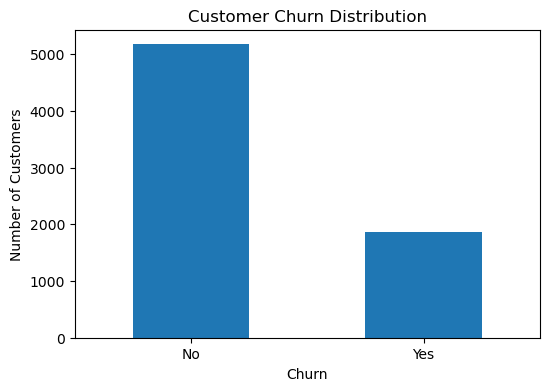

In [16]:
# Churn Distribution
churn_counts = df["Churn"].value_counts()
churn_percent = df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)
print("\nChurn Percentage:")
print(churn_percent)
plt.figure(figsize=(6,4))
churn_counts.plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

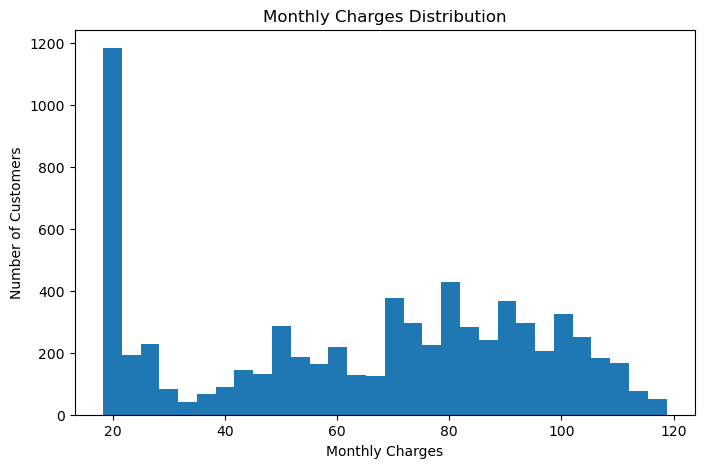

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


In [17]:
# Monthly Charges Distribution
plt.figure(figsize=(8,5))
plt.hist(df["MonthlyCharges"], bins=30)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()
print(df["MonthlyCharges"].describe())

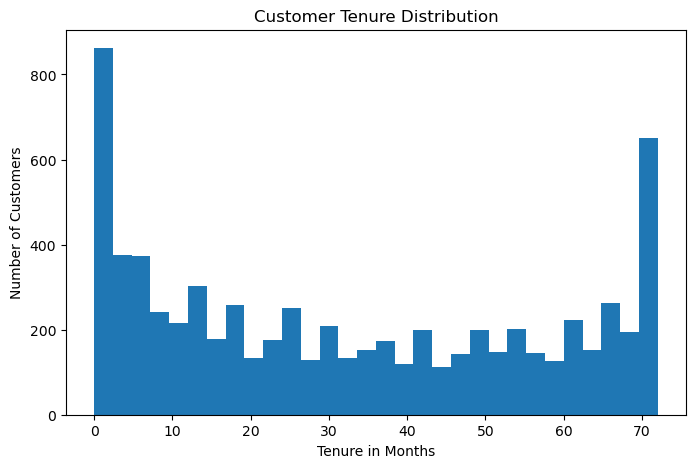

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


In [18]:
#Tenure Distribution
plt.figure(figsize=(8,5))
plt.hist(df["tenure"], bins=30)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure in Months")
plt.ylabel("Number of Customers")
plt.show()
print(df["tenure"].describe())

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


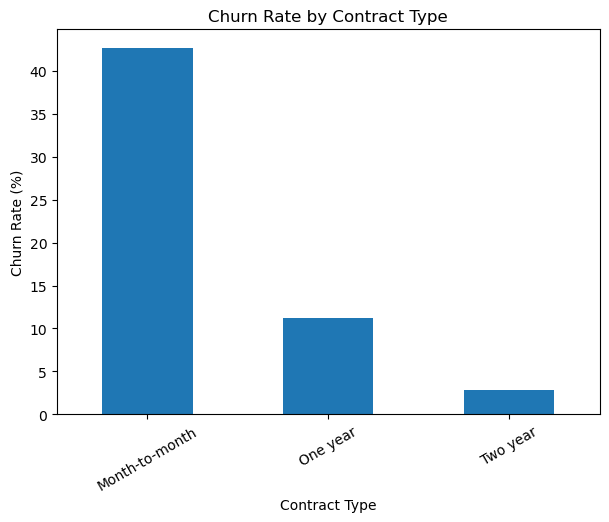

In [19]:
# BIVARIATE ANALYSIS
#Contract Type vs Churn
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
print(contract_churn)
plt.figure(figsize=(7,5))
contract_churn["Yes"].sort_values(ascending=False).plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

Churn                No        Yes
TenureGroup                       
0-6 Months    47.062795  52.937205
7-12 Months   64.113475  35.886525
13-24 Months  71.289062  28.710938
25-48 Months  79.611041  20.388959
49-72 Months  90.486824   9.513176


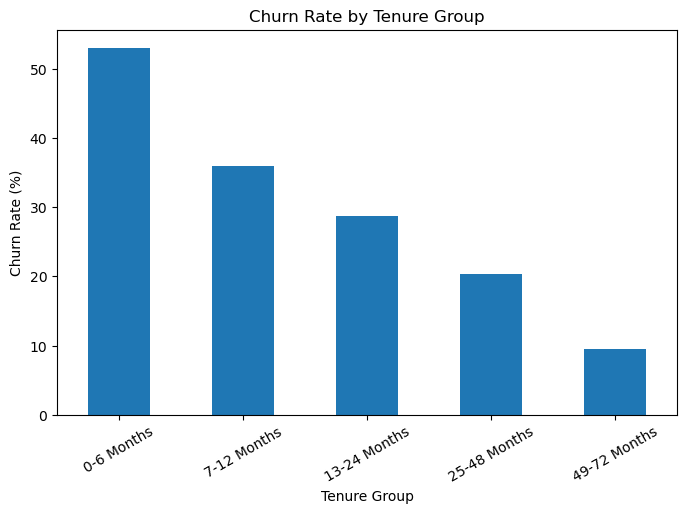

In [23]:
# Tenure Group vs Churn
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=["0-6 Months",
            "7-12 Months",
            "13-24 Months",
            "25-48 Months",
            "49-72 Months"],
    include_lowest=True)

# Churn percentage by tenure group
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index") * 100

print(tenure_churn)

# Plot
plt.figure(figsize=(8,5))

tenure_churn["Yes"].plot(
    kind="bar")

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)

plt.show()

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


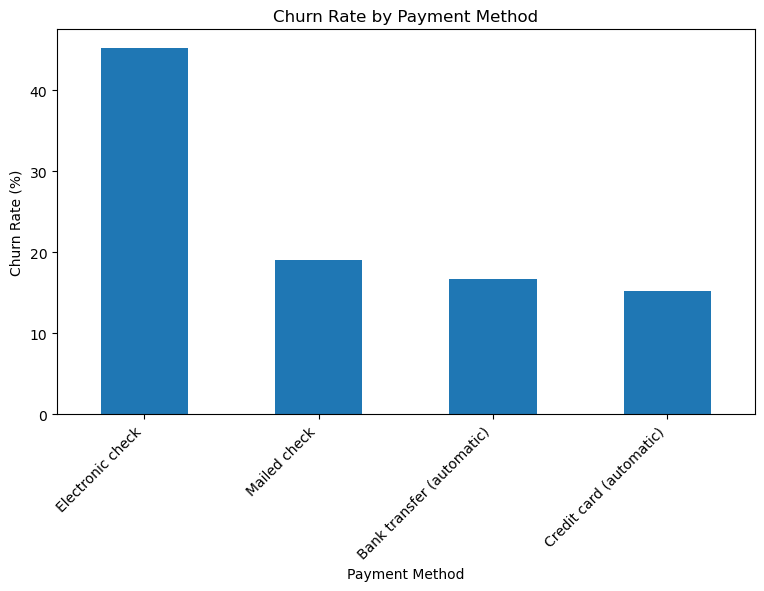

In [25]:
# Payment Method vs Churn
payment_churn = pd.crosstab(df["PaymentMethod"],
                            df["Churn"],
                            normalize="index") * 100

print(payment_churn)

# Plot
plt.figure(figsize=(9,5))

payment_churn["Yes"].sort_values(
    ascending=False).plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=45, ha="right")

plt.show()

Churn                  No       Yes
InternetService                    
DSL              0.810409  0.189591
Fiber optic      0.581072  0.418928
No               0.925950  0.074050


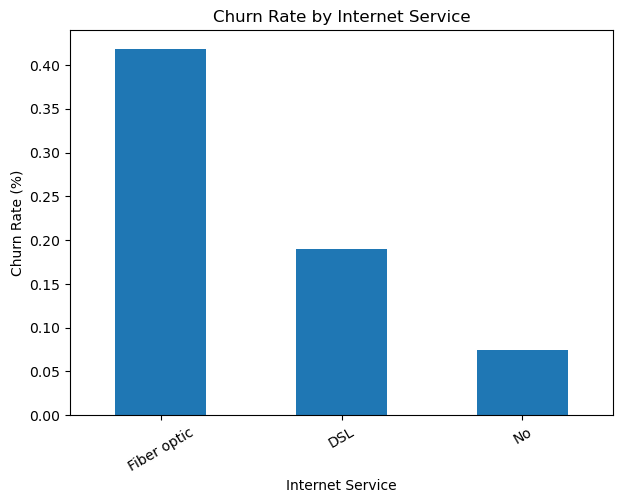

In [26]:
# Internet Service vs Churn
internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index")
print(internet_churn)
plt.figure(figsize=(7,5))
internet_churn["Yes"].sort_values(ascending=False).plot(kind="bar")
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


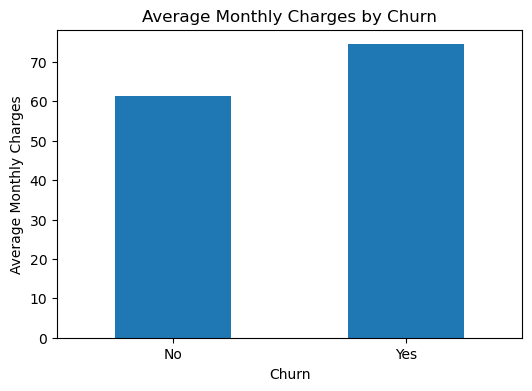

In [28]:
# Monthly Charges by Churn
monthly_by_churn = df.groupby("Churn")["MonthlyCharges"].mean()
print(monthly_by_churn)
plt.figure(figsize=(6,4))
monthly_by_churn.plot(kind="bar")
plt.title("Average Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)
plt.show()

Churn
No     2552.882494
Yes    1531.796094
Name: TotalCharges, dtype: float64


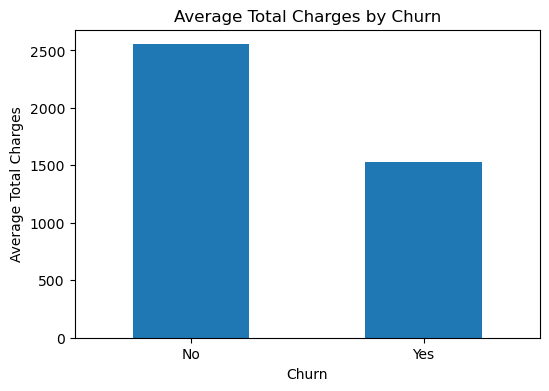

In [29]:
# Total Charges by Churn
total_by_churn = df.groupby("Churn")["TotalCharges"].mean()
print(total_by_churn)
plt.figure(figsize=(6,4))
total_by_churn.plot(kind="bar")
plt.title("Average Total Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Total Charges")
plt.xticks(rotation=0)
plt.show()

Churn               No       Yes
ChargesGroup                    
Low           0.883569  0.116431
Medium        0.760789  0.239211
High          0.621783  0.378217
Very High     0.719512  0.280488


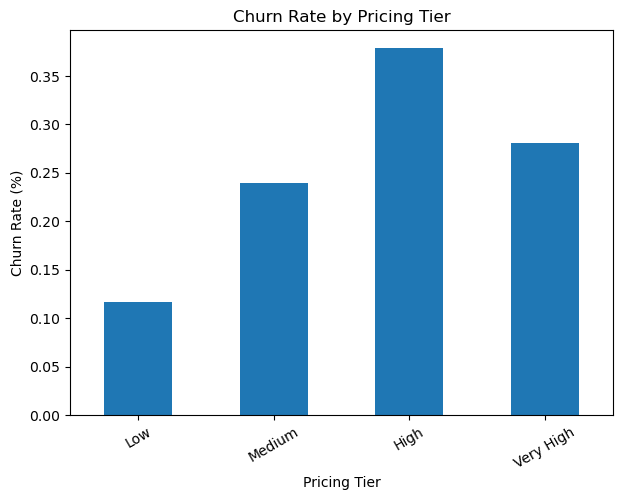

In [31]:
# ADVANCED ANALYTICS
# Pricing Tier Segmentation
df["ChargesGroup"] = pd.cut(
df["MonthlyCharges"],
bins=[0, 40, 70, 100, 120],
labels=["Low", "Medium", "High", "Very High"],
include_lowest=True)
charges_churn = pd.crosstab(df["ChargesGroup"], df["Churn"], normalize="index") * 1
print(charges_churn)
plt.figure(figsize=(7,5))
charges_churn["Yes"].plot(kind="bar")
plt.title("Churn Rate by Pricing Tier")
plt.xlabel("Pricing Tier")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

Churn                No       Yes
SeniorCitizen                    
0              0.763938  0.236062
1              0.583187  0.416813


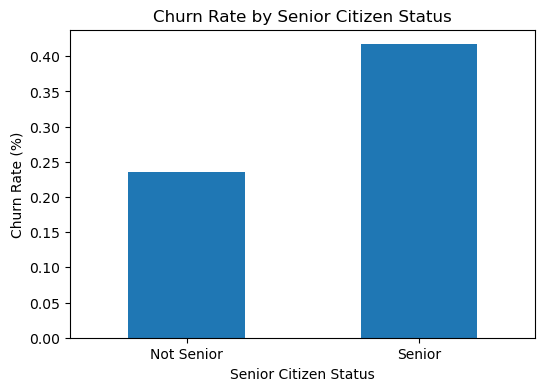

In [32]:
# Senior Citizen vs Churn
senior_churn = pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 1
print(senior_churn)
plt.figure(figsize=(6,4))
senior_churn["Yes"].plot(kind="bar")
plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen Status")
plt.ylabel("Churn Rate (%)")
plt.xticks([0,1], ["Not Senior", "Senior"], rotation=0)
plt.show()

Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237


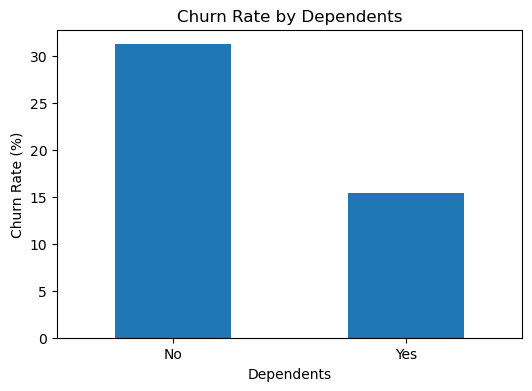

In [34]:
# Dependents vs Churn
dependents_churn = pd.crosstab(df["Dependents"], df["Churn"], normalize="index") * 100
print(dependents_churn)
plt.figure(figsize=(6,4))
dependents_churn["Yes"].plot(kind="bar")
plt.title("Churn Rate by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Churn                      No       Yes
OnlineSecurity                         
No                   0.582333  0.417667
No internet service  0.925950  0.074050
Yes                  0.853888  0.146112


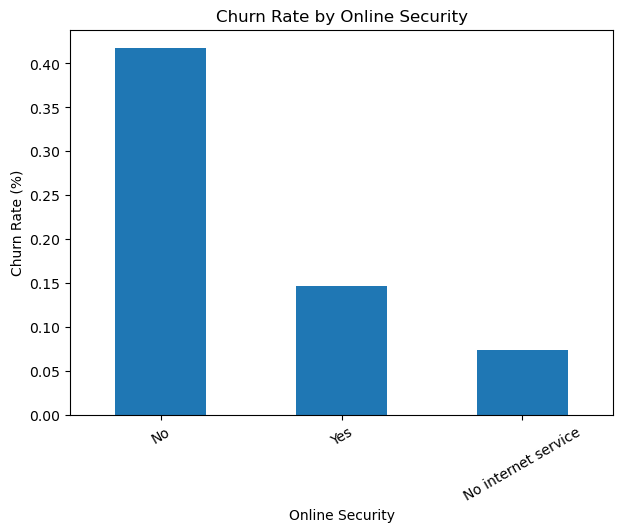

In [35]:
# Online Security vs Churn
security_churn = pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index")
print(security_churn)
plt.figure(figsize=(7,5))
security_churn["Yes"].sort_values(ascending=False).plot(kind="bar")
plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

Churn                      No       Yes
TechSupport                            
No                   5.836453  4.163547
No internet service  9.259502  0.740498
Yes                  8.483366  1.516634


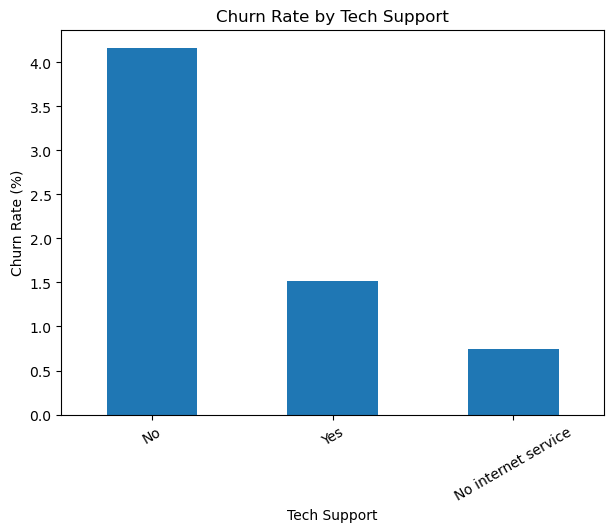

In [36]:
# Tech Support vs Churn
support_churn = pd.crosstab(df["TechSupport"], df["Churn"], normalize="index") * 10
print(support_churn)
plt.figure(figsize=(7,5))
support_churn["Yes"].sort_values(ascending=False).plot(kind="bar")
plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

In [37]:
# Multivariate High-Risk Segment
high_risk = df[
(df["Contract"] == "Month-to-month") &
(df["tenure"] <= 12) &
(df["PaymentMethod"] == "Electronic check")
]
print("High-Risk Customer Count:", len(high_risk))
print("\nHigh-Risk Churn Rate:")
print(high_risk["Churn"].value_counts(normalize=True) * 100)

High-Risk Customer Count: 954

High-Risk Churn Rate:
Churn
Yes    63.102725
No     36.897275
Name: proportion, dtype: float64


In [38]:
# High-Risk Segment with High Charges
very_high_risk = df[
(df["Contract"] == "Month-to-month") &
(df["tenure"] <= 12) &
(df["PaymentMethod"] == "Electronic check") &
    (df["MonthlyCharges"] >= df["MonthlyCharges"].median())]
print("Very High-Risk Customer Count:", len(very_high_risk))
print("\nVery High-Risk Churn Rate:")
print(very_high_risk["Churn"].value_counts(normalize=True) * 100)

Very High-Risk Customer Count: 556

Very High-Risk Churn Rate:
Churn
Yes    71.043165
No     28.956835
Name: proportion, dtype: float64


                  tenure  MonthlyCharges  TotalCharges  ChurnBinary
tenure          1.000000        0.247900      0.825464    -0.352229
MonthlyCharges  0.247900        1.000000      0.650864     0.193356
TotalCharges    0.825464        0.650864      1.000000    -0.199037
ChurnBinary    -0.352229        0.193356     -0.199037     1.000000


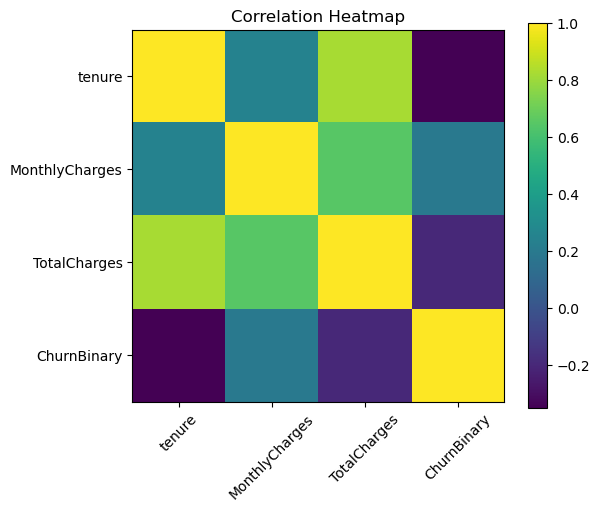

In [40]:
# Correlation Heatmap
numeric_df = df.copy()
numeric_df["ChurnBinary"] = numeric_df["Churn"].map({"No": 0, "Yes": 1})
corr = numeric_df[["tenure", "MonthlyCharges", "TotalCharges", "ChurnBinary"]].corr()
print(corr)
plt.figure(figsize=(6,5))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

# PREDICTION MODEL

In [ ]:
# Prepare Data for Model

# Remove unnecessary columns
model_df = df.drop(columns=["customerID",
                            "TenureGroup",
                            "ChargesGroup"])

# Convert target variable to numeric
model_df["Churn"] = model_df["Churn"].map({
    "No": 0,
    "Yes": 1})

# Convert categorical variables into dummy variables
model_df = pd.get_dummies(model_df,
                          drop_first=True)

# Features and target
X = model_df.drop("Churn",
                  axis=1)

y = model_df["Churn"]

# Shapes
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (7043, 30)
Target Shape: (7043,)


In [45]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=0,
stratify=y)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5634, 30)
Testing Data: (1409, 30)


In [46]:
# Scale and Train Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(
max_iter=1000,
class_weight="balanced",
random_state=0
)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [47]:
#Model Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.752306600425834
Precision: 0.5215889464594128
Recall: 0.8074866310160428
F1 Score: 0.633788037775446
ROC AUC: 0.8512800640677879

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



[[758 277]
 [ 72 302]]


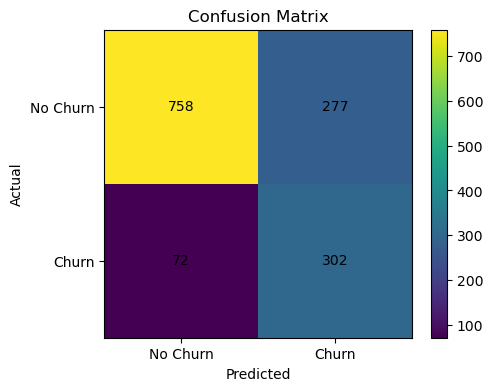

In [51]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

# Plot
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1],
           ["No Churn", "Churn"])
plt.yticks([0,1],
           ["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add values inside matrix
for i in range(2):
    for j in range(2):
        plt.text(j,
                 i,
                 cm[i, j],
                 ha="center",
                 va="center")
plt.show()

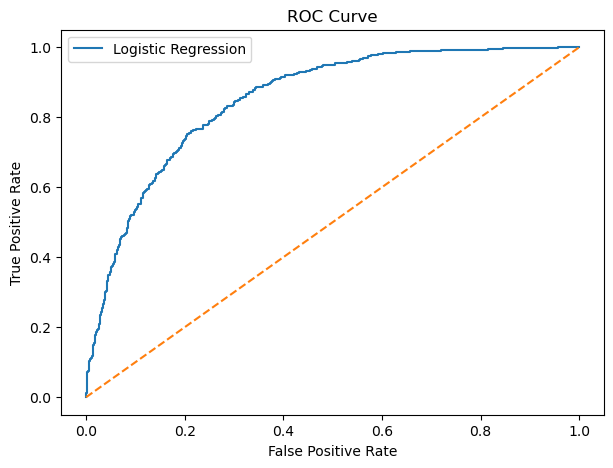

In [52]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

                                 Feature  Coefficient  AbsoluteCoefficient
1                                 tenure    -1.298907             1.298907
2                         MonthlyCharges    -0.666477             0.666477
3                           TotalCharges     0.658773             0.658773
25                     Contract_Two year    -0.623754             0.623754
10           InternetService_Fiber optic     0.604342             0.604342
24                     Contract_One year    -0.302229             0.302229
23                   StreamingMovies_Yes     0.201554             0.201554
21                       StreamingTV_Yes     0.198168             0.198168
28        PaymentMethod_Electronic check     0.152711             0.152711
13                    OnlineSecurity_Yes    -0.152484             0.152484
9                      MultipleLines_Yes     0.152179             0.152179
26                  PaperlessBilling_Yes     0.148798             0.148798
19                       

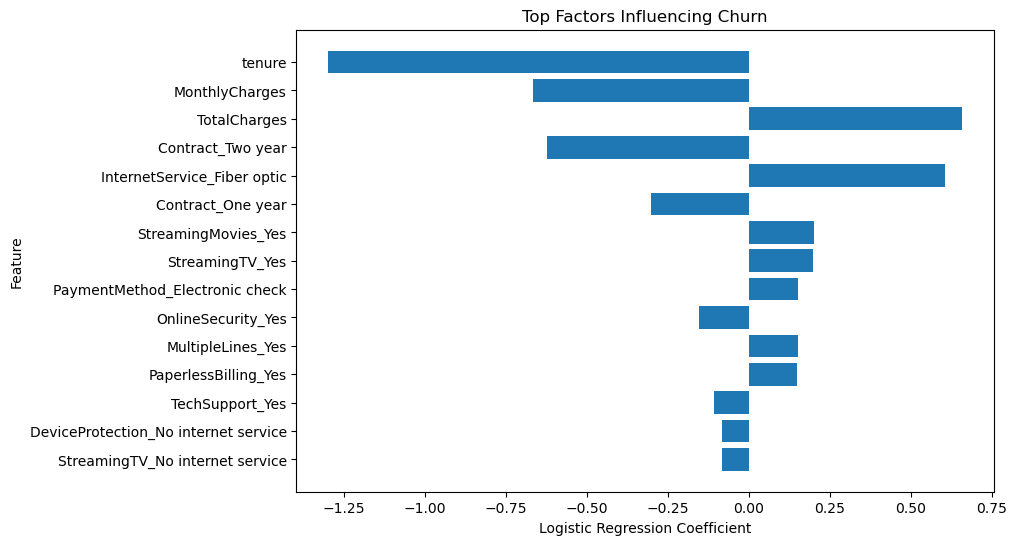

In [53]:
# Feature Importance
importance = pd.DataFrame({
"Feature": X.columns,
"Coefficient": model.coef_[0]})
importance["AbsoluteCoefficient"] = importance["Coefficient"].abs()
top_features = importance.sort_values("AbsoluteCoefficient",
                                      ascending=False).head(15)
print(top_features)
plt.figure(figsize=(9,6))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.title("Top Factors Influencing Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

# FINAL AUTOMATED INSIGHTS
# Final Summary Output

In [56]:
overall_churn = df["Churn"].value_counts(normalize=True)["Yes"] * 100

month_to_month_churn = contract_churn.loc["Month-to-month", "Yes"]

two_year_churn = contract_churn.loc["Two year", "Yes"]

early_churn = tenure_churn.loc["0-6 Months", "Yes"]

electronic_churn = payment_churn.loc["Electronic check", "Yes"]

fiber_churn = internet_churn.loc["Fiber optic", "Yes"]

print("FINAL DATA ANALYTICS SUMMARY")
print("----------------------------------")

print(f"Overall churn rate: {overall_churn:.2f}%")
print(f"Month-to-month churn rate: {month_to_month_churn:.2f}%")
print(f"Two-year contract churn rate: {two_year_churn:.2f}%")
print(f"0-6 month customer churn rate: {early_churn:.2f}%")
print(f"Electronic check churn rate: {electronic_churn:.2f}%")
print(f"Fiber optic churn rate: {fiber_churn:.2f}%")

print("""

KEY FINDINGS:

1. Customer churn is not random. It is strongly linked to contract type, tenure, payment method, and monthly charges.

2. Month-to-month customers are the highest churn group, showing that weak customer commitment increases churn risk.

3. New customers in the first 0-6 months show the highest churn risk, meaning onboarding and early engagement are critical.

4. Electronic check users have a much higher churn rate compared to other payment methods.

5. Fiber optic customers show higher churn, which may indicate pricing pressure, service expectations, or customer dissatisfaction.

6. Customers with month-to-month contracts, low tenure, and electronic check payments form the highest-risk customer segment.

BUSINESS RECOMMENDATIONS:

1. Target customers in their first 6-12 months with onboarding support and retention offers.

2. Encourage month-to-month customers to move into one-year or two-year contracts using discounts or loyalty benefits.

3. Improve perceived value for customers paying higher monthly charges.

4. Review the customer experience for fiber optic users to identify service or pricing issues.

5. Use churn risk scoring models to prioritize customer retention campaigns.

6. Implement personalized retention strategies for high-risk customers before contract cancellation occurs.

""")

FINAL DATA ANALYTICS SUMMARY
----------------------------------
Overall churn rate: 26.54%
Month-to-month churn rate: 42.71%
Two-year contract churn rate: 2.83%
0-6 month customer churn rate: 52.94%
Electronic check churn rate: 45.29%
Fiber optic churn rate: 0.42%


KEY FINDINGS:

1. Customer churn is not random. It is strongly linked to contract type, tenure, payment method, and monthly charges.

2. Month-to-month customers are the highest churn group, showing that weak customer commitment increases churn risk.

3. New customers in the first 0-6 months show the highest churn risk, meaning onboarding and early engagement are critical.

4. Electronic check users have a much higher churn rate compared to other payment methods.

5. Fiber optic customers show higher churn, which may indicate pricing pressure, service expectations, or customer dissatisfaction.

6. Customers with month-to-month contracts, low tenure, and electronic check payments form the highest-risk customer segment.

BUSI